TAHAP 1: SIMULASI DATA SPASIAL
INFORMASI DATA ZINC

Statistik Zinc Asli:
count     155.000000
mean      469.716129
std       367.073788
min       113.000000
25%       198.000000
50%       326.000000
75%       674.500000
max      1839.000000
Name: zinc, dtype: float64

Statistik Log Zinc:
count    155.000000
mean       5.889266
std        0.719804
min        4.736198
25%        5.293305
50%        5.789960
75%        6.515451
max        7.517521
Name: log_zinc, dtype: float64

Informasi Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   x         155 non-null    int64  
 1   y         155 non-null    int64  
 2   zinc      155 non-null    int64  
 3   log_zinc  155 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 5.0 KB
None

5 Data Awal:
        x       y  zinc  log_zinc
0  181072  333611  1022  6.930495
1  181025  333558  1141  7.0

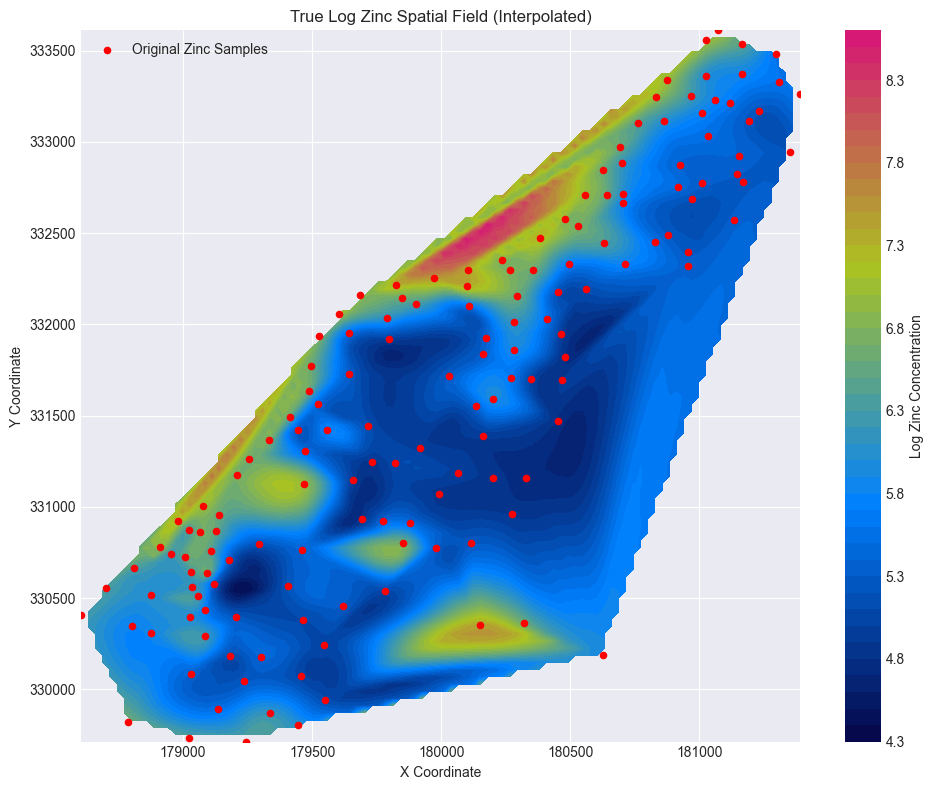

In [2]:
# =============================================================================
# 1. IMPORT LIBRARY
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import pdist, squareform
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from pykrige.ok import OrdinaryKriging
from pykrige.kriging_tools import write_asc_grid

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

# =============================================================================
# 2. SIMULASI DATA SPASIAL DENGAN STRUKTUR AUTOKORELASI
# =============================================================================

print("="*80)
print("TAHAP 1: SIMULASI DATA SPASIAL")
print("="*80)

# =============================================================================
# Membaca data penelitian Zinc
# =============================================================================

data = pd.read_excel(
    "soil.xlsx"
)

# =============================================================================
# INFORMASI DATA ZINC
# =============================================================================

print("="*80)
print("INFORMASI DATA ZINC")
print("="*80)

print("\nStatistik Zinc Asli:")
print(
    data["zinc"].describe()
)

print("\nStatistik Log Zinc:")
print(
    data["log_zinc"].describe()
)

print("\nInformasi Data:")
print(
    data.info()
)

print("\n5 Data Awal:")
print(
    data.head()
)

# =============================================================================
# PEMBENTUKAN GRID SPASIAL
# =============================================================================

# jumlah grid simulasi
nx = 100
ny = 100

# Membuat koordinat grid
grid_x = np.linspace(
    data["x"].min(),
    data["x"].max(),
    nx
)

grid_y = np.linspace(
    data["y"].min(),
    data["y"].max(),
    ny
)

X, Y = np.meshgrid(
    grid_x,
    grid_y
)
print("\nParameter Grid:")

print(
    f"Grid : {nx} x {ny}"
)
print(
    f"Jumlah titik grid : {nx*ny:,}"
)

# =============================================================================
# INTERPOLASI LOG ZINC MENJADI TRUE FIELD
# =============================================================================

from scipy.interpolate import griddata
true_field_zinc = griddata(
    (
        data["x"],
        data["y"]
    ),
    # menggunakan data yang sudah dilogaritmakan
    data["log_zinc"],
    (
        X,
        Y
    ),
    method="cubic"
)
print("\nStatistik Spatial Field Log Zinc:")
print(
    f"Mean : {np.nanmean(true_field_zinc):.3f}"
)
print(
    f"Std Dev : {np.nanstd(true_field_zinc):.3f}"
)
print(
    f"Min : {np.nanmin(true_field_zinc):.3f}"
)
print(
    f"Max : {np.nanmax(true_field_zinc):.3f}"
)

# =============================================================================
# VISUALISASI TRUE SPATIAL FIELD
# =============================================================================

from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list(
      "blue_fuchsia",
        [
            "#060647",
            "#0080FF",
            "#ABC320",
            "#D71576"
        ]
    )
plt.figure(figsize=(10,8))
contour = plt.contourf(
    X,
    Y,
    true_field_zinc,
    levels=50,
    cmap=custom_cmap
)
plt.scatter(
    data["x"],
    data["y"],
    c="red",
    s=20,
    label="Original Zinc Samples"
)
plt.colorbar(
    contour,
    label="Log Zinc Concentration"
)
plt.xlabel(
    "X Coordinate"
)
plt.ylabel(
    "Y Coordinate"
)
plt.title(
    "True Log Zinc Spatial Field (Interpolated)"
)
plt.legend()
plt.tight_layout()
plt.show()


TAHAP 2: SAMPLING DATA
Jumlah titik observasi:
100

Statistik Sampel Zinc:
Mean : 5.724
Std  : 0.712

Data Sampling:
               x              y  zinc_true  zinc_observed
0  179026.969697  329950.181818   5.385182       5.393533
1  179223.888889  329871.454545   5.908829       5.900939
2  180574.191919  333059.909091   7.450336       7.357917
3  179955.303030  332272.636364   7.686739       7.677605
4  180377.272727  332272.636364   6.376976       6.384640


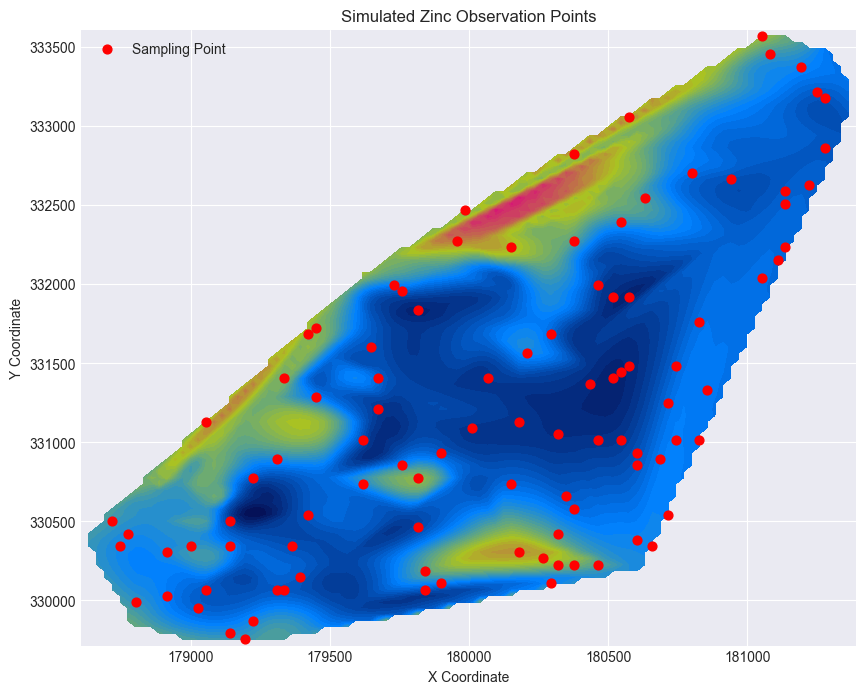

In [3]:
# =============================================================================
# 3. SAMPLING DATA (SIMULASI OBSERVASI)
# =============================================================================

print("\n" + "="*80)
print("TAHAP 2: SAMPLING DATA")
print("="*80)

# Jumlah titik observasi simulasi
n_samples = 100

# Menghilangkan nilai kosong hasil interpolasi
valid_mask = ~np.isnan(true_field_zinc.flatten())

# indeks lokasi yang valid
valid_indices = np.where(valid_mask)[0]

# memilih titik observasi secara random
np.random.seed(42)
sample_indices = np.random.choice(
    valid_indices,
    n_samples,
    replace=False
)

# Mengambil koordinat sampel
sample_x = X.flatten()[sample_indices]
sample_y = Y.flatten()[sample_indices]

# Mengambil nilai zinc sebenarnya
sample_zinc = true_field_zinc.flatten()[sample_indices]

print("Jumlah titik observasi:")
print(len(sample_zinc))

# =============================================================================
# MENAMBAHKAN ERROR PENGUKURAN
# =============================================================================

noise_std = 0.05 * np.std(sample_zinc)
sample_zinc_noisy = (
    sample_zinc +
    np.random.normal(
        0,
        noise_std,
        n_samples
    )
)
print("\nStatistik Sampel Zinc:")
print(
    f"Mean : {sample_zinc_noisy.mean():.3f}"
)
print(
    f"Std  : {sample_zinc_noisy.std():.3f}"
)

# =============================================================================
# DATA OBSERVASI HASIL SAMPLING
# =============================================================================
sample_data = pd.DataFrame({
    "x": sample_x,
    "y": sample_y,
    "zinc_true": sample_zinc,
    "zinc_observed": sample_zinc_noisy
})
print("\nData Sampling:")
print(sample_data.head())

# =============================================================================
# VISUALISASI TITIK OBSERVASI
# =============================================================================

custom_cmap = LinearSegmentedColormap.from_list(
    "blue_fuchsia",
    [
        "#060647",
        "#0080FF",
        "#ABC320",
        "#D71576"
    ]
)
plt.figure(figsize=(10,8))
plt.contourf(
    X,
    Y,
    true_field_zinc,
    levels=50,
    cmap=custom_cmap
)

plt.scatter(
    sample_x,
    sample_y,
    c="red",
    s=40,
    label="Sampling Point"
)
plt.colorbar(
    contour,
    label="Zinc"
)
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title(
    "Simulated Zinc Observation Points"
)
plt.legend()
plt.show()


TAHAP 3: ANALISIS VARIOGRAM
Jumlah titik observasi:
100
Ukuran matriks jarak:
(100, 100)
Jumlah pasangan titik:
4950
      distance  semivariance
0   212.073458      0.128730
1  3473.370167      1.929401
2  2501.119328      2.608492
3  2686.468572      0.491146
4  2018.482884      0.067157
   distance_mean  semivariance_mean  pair_count
0     143.943199           0.145571         114
1     339.573163           0.369262         273
2     532.549505           0.381631         401
3     746.093141           0.558362         459
4     952.467477           0.592861         513


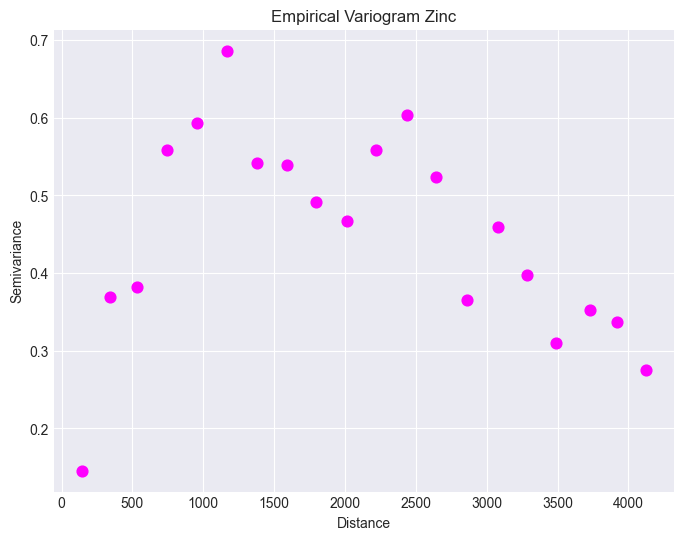

In [4]:
# =============================================================================
# 4. ANALISIS VARIOGRAM
# =============================================================================

print("\n" + "="*80)
print("TAHAP 3: ANALISIS VARIOGRAM")
print("="*80)

# Koordinat titik observasi
coords = np.column_stack(
    (
        sample_data["x"],
        sample_data["y"]
    )
)

# Nilai zinc hasil pengamatan
values = sample_data["zinc_observed"].values

print("Jumlah titik observasi:")
print(len(values))

# Matriks jarak antar titik
distance_matrix = squareform(
    pdist(coords)
)

print("Ukuran matriks jarak:")
print(distance_matrix.shape)

# Menyimpan hasil variogram
variogram_data = []

for i in range(len(values)):
    for j in range(i+1, len(values)):
        distance = distance_matrix[i,j]
        semivariance = (
            (values[i]-values[j])**2
        ) / 2
        variogram_data.append(
            [
                distance,
                semivariance
            ]
        )

print(
    "Jumlah pasangan titik:"
)
print(
    len(variogram_data)
)
variogram_df = pd.DataFrame(
    variogram_data,
    columns=[
        "distance",
        "semivariance"
    ]
)
print(
    variogram_df.head()
)

# =============================================================================
# PEMBENTUKAN LAG VARIOGRAM
# =============================================================================

n_lags = 20
max_distance = variogram_df["distance"].max()
bins = np.linspace(
    0,
    max_distance,
    n_lags+1
)
variogram_df["lag"] = pd.cut(
    variogram_df["distance"],
    bins=bins
)
empirical_variogram = (
    variogram_df
    .groupby("lag", observed=True)
    .agg(
        distance_mean=("distance","mean"),
        semivariance_mean=("semivariance","mean"),
        pair_count=("semivariance","count")
    )
    .reset_index(drop=True)
)
print(
    empirical_variogram.head()
)

# =============================================================================
# VISUALISASI VARIOGRAM EMPIRIS
# =============================================================================

plt.figure(figsize=(8,6))
plt.scatter(
    empirical_variogram["distance_mean"],
    empirical_variogram["semivariance_mean"],
    s=60,
    color="#FF00FF"
)
plt.xlabel(
    "Distance"
)
plt.ylabel(
    "Semivariance"
)
plt.title(
    "Empirical Variogram Zinc"
)
plt.grid(True)
plt.show()


TAHAP 4: FITTING MODEL VARIOGRAM TEORITIS
Jumlah lag variogram:
20
Parameter Exponential:
[ -0.33977805   0.81067468 159.50347232]

Parameter Spherical:
[4.26478144e-02 4.30648541e-01 7.46025448e+02]

Parameter Gaussian:
[8.24752943e-02 3.89077518e-01 3.24138167e+02]

Nilai SSE Model:
Exponential : 0.2259993330259476
Spherical : 0.22513019895592454
Gaussian : 0.2253218643857461

Model terbaik:
Spherical


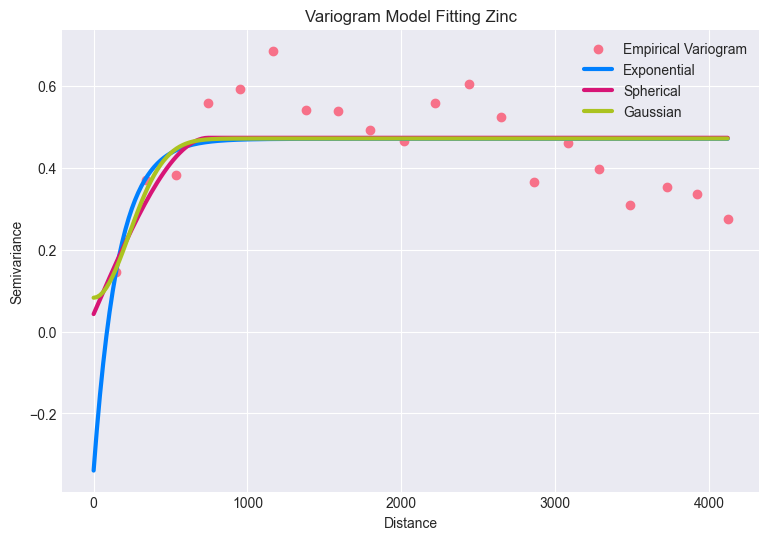

In [5]:
# =============================================================================
# 5. FITTING MODEL VARIOGRAM TEORITIS
# =============================================================================

print("\n" + "="*80)
print("TAHAP 4: FITTING MODEL VARIOGRAM TEORITIS")
print("="*80)

# Data jarak dan semivariance
distance = empirical_variogram["distance_mean"].values
gamma = empirical_variogram["semivariance_mean"].values

print("Jumlah lag variogram:")
print(len(distance))

# =============================================================================
# MODEL EXPONENTIAL
# =============================================================================

def variogram_exponential(
    h,
    nugget,
    sill,
    range_param
):
    return (
        nugget +
        sill *
        (
            1 -
            np.exp(
                -h/range_param
            )
        )
    )

# =============================================================================
# MODEL SPHERICAL
# =============================================================================

def variogram_spherical(
    h,
    nugget,
    sill,
    range_param
):
    gamma = np.zeros(len(h))
    for i, distance in enumerate(h):
        if distance <= range_param:
            gamma[i] = (
                nugget +
                sill *
                (
                    1.5*(distance/range_param)
                    -
                    0.5*(distance/range_param)**3
                )
            )
        else:
            gamma[i] = nugget + sill
    return gamma

# =============================================================================
# MODEL GAUSSIAN
# =============================================================================

def variogram_gaussian(
    h,
    nugget,
    sill,
    range_param
):
    return (
        nugget +
        sill *
        (
            1 -
            np.exp(
                -(h**2) /
                (range_param**2)
            )
        )
    )

# =============================================================================
# FITTING MODEL
# =============================================================================

initial_guess = [
    0.1,                     # nugget
    np.var(values),           # sill
    np.mean(distance)         # range
]

def fit_model(model_function):
    result = minimize(
        lambda params:
        np.sum(
            (
                gamma -
                model_function(
                    distance,
                    params[0],
                    params[1],
                    params[2]
                )
            )**2
        ),
        initial_guess,
        method="Nelder-Mead"
    )
    return result.x

# Fit semua model
params_exp = fit_model(
    variogram_exponential
)
params_sph = fit_model(
    variogram_spherical
)
params_gauss = fit_model(
    variogram_gaussian
)

print("Parameter Exponential:")
print(params_exp)
print("\nParameter Spherical:")
print(params_sph)
print("\nParameter Gaussian:")
print(params_gauss)

# =============================================================================
# PERBANDINGAN MODEL
# =============================================================================

def calculate_sse(
    model_function,
    params
):
    prediction = model_function(
        distance,
        params[0],
        params[1],
        params[2]
    )
    return np.sum(
        (
            gamma -
            prediction
        )**2
    )

sse_values = {
    "Exponential":
    calculate_sse(
        variogram_exponential,
        params_exp
    ),

    "Spherical":
    calculate_sse(
        variogram_spherical,
        params_sph
    ),

    "Gaussian":
    calculate_sse(
        variogram_gaussian,
        params_gauss
    )
}

print("\nNilai SSE Model:")
for model, error in sse_values.items():
    print(
        model,
        ":",
        error
    )

# Model dengan SSE terkecil
best_model = min(
    sse_values,
    key=sse_values.get
)

print(
    "\nModel terbaik:"
)

print(
    best_model
)

# =============================================================================
# VISUALISASI FITTING
# =============================================================================

plt.figure(figsize=(9,6))
plt.scatter(
    distance,
    gamma,
    label="Empirical Variogram"
)
h_line = np.linspace(
    0,
    max(distance),
    200
)

# Exponential Model
plt.plot(
    h_line,
    variogram_exponential(
        h_line,
        *params_exp
    ),
    color="#0080FF",  
    linewidth=3,
    label="Exponential"
)

#Spherical Model
plt.plot(
    h_line,
    variogram_spherical(
        h_line,
        *params_sph
    ),
    color="#D71576",
    linewidth=3,
    label="Spherical"
)

#Gaussian Model
plt.plot(
    h_line,
    variogram_gaussian(
        h_line,
        *params_gauss
    ),
    color="#ABC320",
    linewidth=3,
    label="Gaussian"
)
plt.xlabel(
    "Distance"
)
plt.ylabel(
    "Semivariance"
)
plt.title(
    "Variogram Model Fitting Zinc"
)
plt.legend()
plt.grid(True)
plt.show()